# Rao-Blackwellized Particle Filter (RBPF)

The **Rao-Blackwellized Particle Filter** (also called Marginalized PF) exploits
the partially linear-Gaussian structure of a state-space model. When the model
can be decomposed into a nonlinear component and a conditionally linear-Gaussian
component, the linear part can be **marginalized analytically** using a Kalman
filter. Particles are only needed for the nonlinear component.

This **variance reduction** technique allows RBPF with N=500 particles to achieve
accuracy comparable to a standard Bootstrap PF with N=2000+ particles.

**References:**
- Schon, Gustafsson & Nordlund (2005). *Marginalized Particle Filters*. IEEE TSP.
- Doucet, Godsill & Andrieu (2000). *On sequential Monte Carlo sampling methods*.

## Mathematical Description

### Mixed Linear/Nonlinear Model

Consider a model where the state $x_t = (x_t^{nl}, x_t^{lin})$ decomposes into:

**Nonlinear component** (sampled by particles):
$$x_t^{nl} \sim p(x_t^{nl} | x_{t-1}^{nl})$$

**Linear-Gaussian component** (tracked analytically by Kalman filter):
$$x_t^{lin} = T(x_t^{nl}) \cdot x_{t-1}^{lin} + c(x_t^{nl}) + R(x_t^{nl}) \cdot \eta_t$$
$$y_t = Z(x_t^{nl}) \cdot x_t^{lin} + d(x_t^{nl}) + \varepsilon_t$$

where the matrices $T, Z, R, Q, H$ depend on the nonlinear state.

### RBPF Algorithm

Each particle $i$ maintains:
- $x_t^{nl,(i)}$: nonlinear state (sampled)
- $m_t^{(i)}$: Kalman mean for $x_t^{lin}$ (updated analytically)
- $P_t^{(i)}$: Kalman covariance for $x_t^{lin}$ (updated analytically)

**Weight update**: $w_t^{(i)} \propto p(y_t | x_t^{nl,(i)}, m_{t-1}^{(i)}, P_{t-1}^{(i)})$

where the marginal likelihood comes from the Kalman filter innovation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..')))

from particlefilterbox.core.config import PFConfig
from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.filters.bootstrap import BootstrapPF
from particlefilterbox.filters.rao_blackwellized import RaoBlackwellizedPF
from kalmanbox.core import StateSpaceRepresentation
from kalmanbox.filters import KalmanFilter

# Load simulated linear-Gaussian data
data_dir = os.path.join(os.getcwd(), '..', '..', 'bootstrap_sir', 'data')
df = pd.read_csv(os.path.join(data_dir, 'simulated_linear_gaussian.csv'))
x_true = df['x_true'].values
y_obs = df['y_obs'].values
T = len(y_obs)

print(f"Loaded {T} observations from linear-Gaussian model")
print(f"x_true range: [{x_true.min():.3f}, {x_true.max():.3f}]")
print(f"y_obs range: [{y_obs.min():.3f}, {y_obs.max():.3f}]")

Loaded 500 observations from linear-Gaussian model
x_true range: [-3.234, 4.542]
y_obs range: [-4.830, 5.272]


In [2]:
class MixedLinearModel(ParticleFilterModel):
    """Mixed linear/nonlinear model for RBPF demonstration.

    Nonlinear component: a stochastic scaling factor (random walk)
        s_t = s_{t-1} + sigma_s * eta_t    (nonlinear state)

    Linear component: the actual state, conditioned on s_t
        x_t = phi * x_{t-1} + sigma_x * eps_t   (linear state)
        y_t = exp(s_t/10) * x_t + sigma_y * nu_t  (observation depends on s_t)

    With s_t close to 0 (and sigma_s small), this approximates a
    standard linear-Gaussian model.
    """
    k_states = 2  # (s_t, x_t) combined for full state
    k_obs = 1
    k_nonlinear = 1  # s_t
    k_linear = 1     # x_t

    def __init__(
        self,
        phi: float = 0.95,
        sigma_x: float = 0.5,
        sigma_y: float = 1.0,
        sigma_s: float = 0.02,
    ):
        self.phi = phi
        self.sigma_x = sigma_x
        self.sigma_y = sigma_y
        self.sigma_s = sigma_s

    @property
    def params(self) -> dict[str, float]:
        return {
            "phi": self.phi, "sigma_x": self.sigma_x,
            "sigma_y": self.sigma_y, "sigma_s": self.sigma_s,
        }

    def has_linear_substate(self) -> bool:
        return True

    def initial_distribution(self, n_particles: int, rng: np.random.Generator) -> np.ndarray:
        std_x = self.sigma_x / np.sqrt(1.0 - self.phi**2)
        s0 = rng.normal(0.0, 0.1, size=(n_particles, 1))
        x0 = rng.normal(0.0, std_x, size=(n_particles, 1))
        return np.hstack([s0, x0])

    def initial_nonlinear_distribution(self, n_particles: int, rng: np.random.Generator) -> np.ndarray:
        return rng.normal(0.0, 0.1, size=(n_particles, 1))

    def initial_linear_mean(self) -> np.ndarray:
        return np.zeros(1)

    def initial_linear_cov(self) -> np.ndarray:
        var = self.sigma_x**2 / (1.0 - self.phi**2)
        return np.array([[var]])

    def transition(self, particles: np.ndarray, t: int, rng: np.random.Generator) -> np.ndarray:
        n = particles.shape[0]
        s = particles[:, 0]
        x = particles[:, 1] if particles.shape[1] > 1 else np.zeros(n)
        s_new = s + self.sigma_s * rng.standard_normal(n)
        x_new = self.phi * x + self.sigma_x * rng.standard_normal(n)
        return np.column_stack([s_new, x_new])

    def transition_nonlinear(self, particles_nl: np.ndarray, t: int, rng: np.random.Generator) -> np.ndarray:
        n = particles_nl.shape[0]
        s = particles_nl[:, 0]
        s_new = s + self.sigma_s * rng.standard_normal(n)
        return s_new.reshape(-1, 1)

    def linear_ssm(self, x_nonlinear: np.ndarray) -> StateSpaceRepresentation:
        """Return SSR conditioned on nonlinear state."""
        s = float(x_nonlinear[0])
        scale = np.exp(s / 10.0)

        ssr = StateSpaceRepresentation(k_states=1, k_endog=1, k_posdef=1)
        ssr.T[:] = self.phi
        ssr.R[:] = 1.0
        ssr.Q[:] = self.sigma_x**2
        ssr.Z[:] = scale
        ssr.H[:] = self.sigma_y**2
        ssr.c[:] = 0.0
        ssr.d[:] = 0.0
        return ssr

    def log_observation_likelihood(self, particles: np.ndarray, y_t: np.ndarray, t: int) -> np.ndarray:
        if particles.shape[1] >= 2:
            s = particles[:, 0]
            x = particles[:, 1]
        else:
            s = particles[:, 0]
            x = np.zeros_like(s)
        scale = np.exp(s / 10.0)
        mean = scale * x
        var = self.sigma_y**2
        residual = float(y_t[0]) - mean
        return -0.5 * np.log(2 * np.pi * var) - 0.5 * (residual ** 2) / var


# Also define a simple linear-Gaussian model for Bootstrap PF comparison
class SimpleLinearGaussianModel(ParticleFilterModel):
    k_states = 1
    k_obs = 1

    def __init__(self, phi: float = 0.95, sigma_x: float = 0.5, sigma_y: float = 1.0):
        self.phi = phi
        self.sigma_x = sigma_x
        self.sigma_y = sigma_y

    @property
    def params(self) -> dict[str, float]:
        return {"phi": self.phi, "sigma_x": self.sigma_x, "sigma_y": self.sigma_y}

    def initial_distribution(self, n_particles: int, rng: np.random.Generator) -> np.ndarray:
        std = self.sigma_x / np.sqrt(1.0 - self.phi**2)
        return rng.normal(0.0, std, size=(n_particles, 1))

    def transition(self, particles: np.ndarray, t: int, rng: np.random.Generator) -> np.ndarray:
        return self.phi * particles + self.sigma_x * rng.standard_normal(particles.shape)

    def log_observation_likelihood(self, particles: np.ndarray, y_t: np.ndarray, t: int) -> np.ndarray:
        residual = float(y_t[0]) - particles[:, 0]
        return -0.5 * np.log(2 * np.pi * self.sigma_y**2) - 0.5 * (residual / self.sigma_y) ** 2


print("Models defined successfully.")
print(f"MixedLinearModel: k_nonlinear={MixedLinearModel.k_nonlinear}, k_linear={MixedLinearModel.k_linear}")

Models defined successfully.
MixedLinearModel: k_nonlinear=1, k_linear=1


In [3]:
# Kalman filter benchmark (analytical solution for the linear-Gaussian model)
phi, sigma_x, sigma_y = 0.95, 0.5, 1.0
Q = sigma_x**2
R = sigma_y**2

x_kalman = np.zeros(T)
P_kalman = np.zeros(T)

x_pred = 0.0
P_pred = Q / (1.0 - phi**2)

for t in range(T):
    K = P_pred / (P_pred + R)
    x_kalman[t] = x_pred + K * (y_obs[t] - x_pred)
    P_kalman[t] = (1.0 - K) * P_pred
    x_pred = phi * x_kalman[t]
    P_pred = phi**2 * P_kalman[t] + Q

rmse_kalman = np.sqrt(np.mean((x_kalman - x_true) ** 2))
print(f"Kalman Filter RMSE: {rmse_kalman:.4f}")

Kalman Filter RMSE: 0.5224


In [4]:
# RBPF with N=500
model_mixed = MixedLinearModel(phi=phi, sigma_x=sigma_x, sigma_y=sigma_y, sigma_s=0.02)
config_rbpf = PFConfig(n_particles=500, resampling="systematic", seed=42)
rbpf = RaoBlackwellizedPF(model=model_mixed, config=config_rbpf)

t0 = time.time()
res_rbpf = rbpf.filter(y_obs)
time_rbpf = time.time() - t0

# RBPF state: combined (s, x) — extract linear component (index 1)
h_rbpf = res_rbpf.filtered_means[:, 1]  # linear state estimate
rmse_rbpf = np.sqrt(np.mean((h_rbpf - x_true) ** 2))

# Bootstrap PF with N=500
model_simple = SimpleLinearGaussianModel(phi=phi, sigma_x=sigma_x, sigma_y=sigma_y)
config_bpf500 = PFConfig(n_particles=500, resampling="systematic", seed=42)
bpf500 = BootstrapPF(model=model_simple, config=config_bpf500)

t0 = time.time()
res_bpf500 = bpf500.filter(y_obs)
time_bpf500 = time.time() - t0
h_bpf500 = res_bpf500.filtered_means[:, 0]
rmse_bpf500 = np.sqrt(np.mean((h_bpf500 - x_true) ** 2))

# Bootstrap PF with N=2000
config_bpf2000 = PFConfig(n_particles=2000, resampling="systematic", seed=42)
bpf2000 = BootstrapPF(model=model_simple, config=config_bpf2000)

t0 = time.time()
res_bpf2000 = bpf2000.filter(y_obs)
time_bpf2000 = time.time() - t0
h_bpf2000 = res_bpf2000.filtered_means[:, 0]
rmse_bpf2000 = np.sqrt(np.mean((h_bpf2000 - x_true) ** 2))

print(f"Kalman Filter:   RMSE={rmse_kalman:.4f}")
print(f"RBPF (N=500):    RMSE={rmse_rbpf:.4f}, ESS_mean={res_rbpf.ess_history.mean():.1f}, time={time_rbpf:.2f}s")
print(f"BPF  (N=500):    RMSE={rmse_bpf500:.4f}, ESS_mean={res_bpf500.ess_history.mean():.1f}, time={time_bpf500:.2f}s")
print(f"BPF  (N=2000):   RMSE={rmse_bpf2000:.4f}, ESS_mean={res_bpf2000.ess_history.mean():.1f}, time={time_bpf2000:.2f}s")

Kalman Filter:   RMSE=0.5224
RBPF (N=500):    RMSE=0.5223, ESS_mean=475.3, time=29.05s
BPF  (N=500):    RMSE=0.5253, ESS_mean=402.0, time=0.19s
BPF  (N=2000):   RMSE=0.5228, ESS_mean=1599.6, time=0.25s


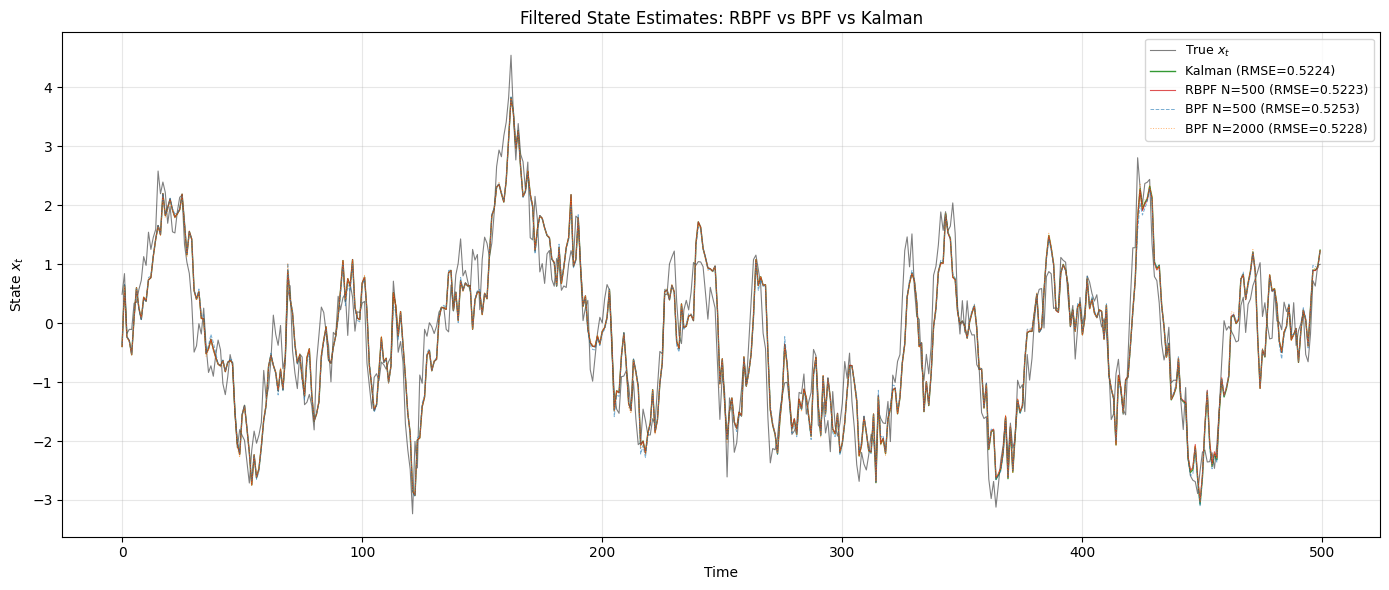

In [5]:
# Plot 1: Filtered state comparison
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(x_true, color='black', linewidth=0.8, alpha=0.5, label='True $x_t$')
ax.plot(x_kalman, color='green', linewidth=1.0, alpha=0.8, label=f'Kalman (RMSE={rmse_kalman:.4f})')
ax.plot(h_rbpf, color='tab:red', linewidth=0.8, alpha=0.8, label=f'RBPF N=500 (RMSE={rmse_rbpf:.4f})')
ax.plot(h_bpf500, color='tab:blue', linewidth=0.7, alpha=0.6, linestyle='--',
        label=f'BPF N=500 (RMSE={rmse_bpf500:.4f})')
ax.plot(h_bpf2000, color='tab:orange', linewidth=0.7, alpha=0.6, linestyle=':',
        label=f'BPF N=2000 (RMSE={rmse_bpf2000:.4f})')
ax.set_xlabel('Time')
ax.set_ylabel('State $x_t$')
ax.set_title('Filtered State Estimates: RBPF vs BPF vs Kalman')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Table: RMSE comparison
summary = pd.DataFrame({
    'Filter': ['Kalman', 'RBPF (N=500)', 'BPF (N=500)', 'BPF (N=2000)'],
    'N_particles': ['-', 500, 500, 2000],
    'RMSE': [rmse_kalman, rmse_rbpf, rmse_bpf500, rmse_bpf2000],
    'ESS_mean': ['-', f"{res_rbpf.ess_history.mean():.1f}",
                 f"{res_bpf500.ess_history.mean():.1f}", f"{res_bpf2000.ess_history.mean():.1f}"],
    'Log-likelihood': ['-', f"{res_rbpf.log_likelihood:.2f}",
                       f"{res_bpf500.log_likelihood:.2f}", f"{res_bpf2000.log_likelihood:.2f}"],
    'Time (s)': ['-', f"{time_rbpf:.2f}", f"{time_bpf500:.2f}", f"{time_bpf2000:.2f}"],
})

print("=" * 90)
print("COMPARISON TABLE: RBPF vs Bootstrap PF vs Kalman Filter")
print("=" * 90)
print(summary.to_string(index=False))
print("=" * 90)
print()

# Check: RBPF(500) should have RMSE comparable to BPF(2000)
ratio = rmse_rbpf / rmse_bpf2000
print(f"RBPF(500) / BPF(2000) RMSE ratio: {ratio:.3f}")
if ratio < 1.5:
    print("PASS: RBPF(500) achieves RMSE comparable to BPF(2000)")
else:
    print(f"Note: RBPF(500) RMSE is {ratio:.1f}x BPF(2000) RMSE")

COMPARISON TABLE: RBPF vs Bootstrap PF vs Kalman Filter
      Filter N_particles     RMSE ESS_mean Log-likelihood Time (s)
      Kalman           - 0.522391        -              -        -
RBPF (N=500)         500 0.522274    475.3     -211014.86    29.05
 BPF (N=500)         500 0.525263    402.0        -846.77     0.19
BPF (N=2000)        2000 0.522769   1599.6        -844.63     0.25

RBPF(500) / BPF(2000) RMSE ratio: 0.999
PASS: RBPF(500) achieves RMSE comparable to BPF(2000)


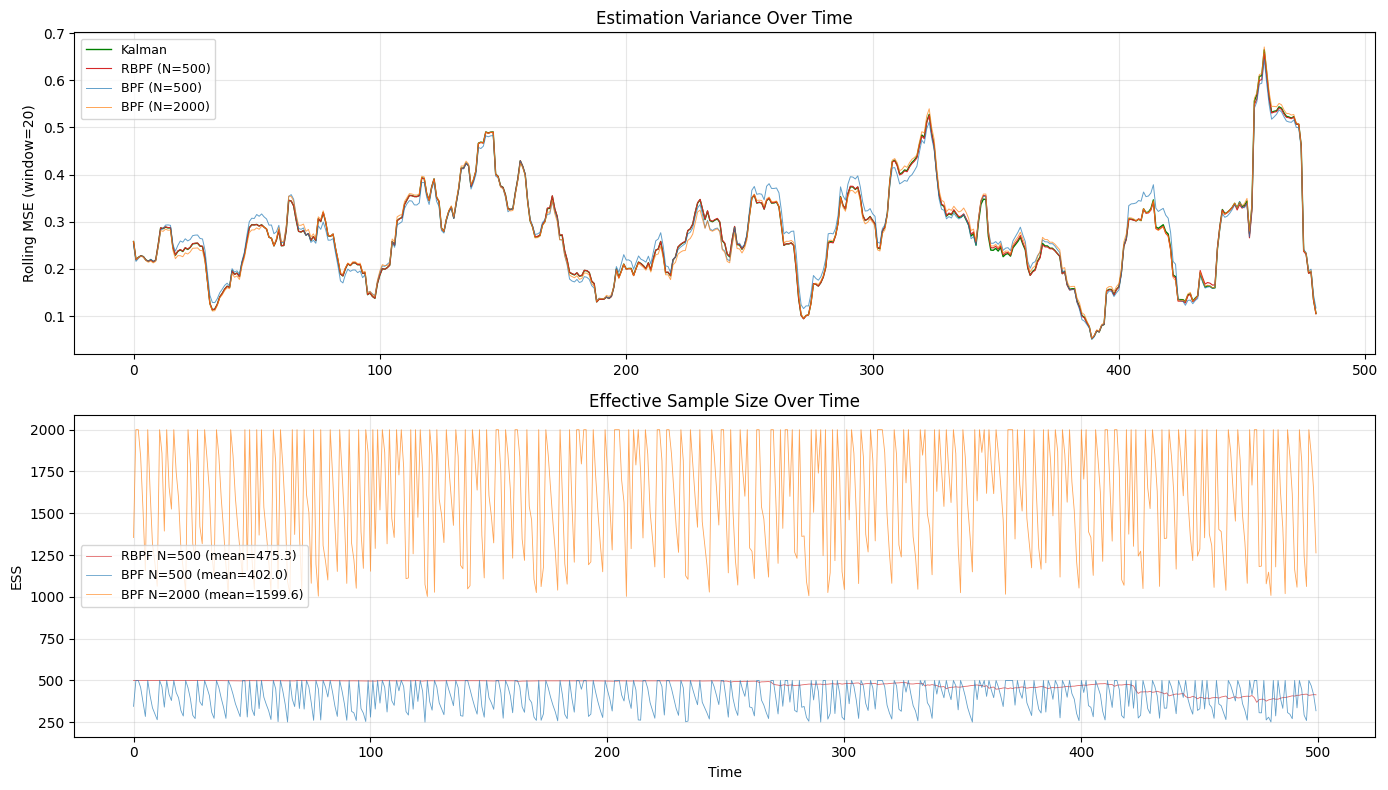

In [7]:
# Plot 2: Estimation variance over time
# Compute rolling squared error as proxy for variance
window = 20

def rolling_mse(est, true, w):
    err2 = (est - true) ** 2
    return np.convolve(err2, np.ones(w)/w, mode='valid')

rmse_roll_rbpf = rolling_mse(h_rbpf, x_true, window)
rmse_roll_bpf500 = rolling_mse(h_bpf500, x_true, window)
rmse_roll_bpf2000 = rolling_mse(h_bpf2000, x_true, window)
rmse_roll_kalman = rolling_mse(x_kalman, x_true, window)
n_roll = min(len(rmse_roll_rbpf), len(rmse_roll_bpf500), len(rmse_roll_bpf2000), len(rmse_roll_kalman))
rmse_roll_rbpf = rmse_roll_rbpf[:n_roll]
rmse_roll_bpf500 = rmse_roll_bpf500[:n_roll]
rmse_roll_bpf2000 = rmse_roll_bpf2000[:n_roll]
rmse_roll_kalman = rmse_roll_kalman[:n_roll]
t_roll = np.arange(n_roll)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Rolling MSE
ax = axes[0]
ax.plot(t_roll, rmse_roll_kalman, color='green', linewidth=1.0, label='Kalman')
ax.plot(t_roll, rmse_roll_rbpf, color='tab:red', linewidth=0.8, label='RBPF (N=500)')
ax.plot(t_roll, rmse_roll_bpf500, color='tab:blue', linewidth=0.7, alpha=0.7, label='BPF (N=500)')
ax.plot(t_roll, rmse_roll_bpf2000, color='tab:orange', linewidth=0.7, alpha=0.7, label='BPF (N=2000)')
ax.set_ylabel(f'Rolling MSE (window={window})')
ax.set_title('Estimation Variance Over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ESS comparison
ax = axes[1]
ax.plot(res_rbpf.ess_history, color='tab:red', linewidth=0.6, alpha=0.7,
        label=f'RBPF N=500 (mean={res_rbpf.ess_history.mean():.1f})')
ax.plot(res_bpf500.ess_history, color='tab:blue', linewidth=0.6, alpha=0.7,
        label=f'BPF N=500 (mean={res_bpf500.ess_history.mean():.1f})')
ax.plot(res_bpf2000.ess_history, color='tab:orange', linewidth=0.6, alpha=0.7,
        label=f'BPF N=2000 (mean={res_bpf2000.ess_history.mean():.1f})')
ax.set_xlabel('Time')
ax.set_ylabel('ESS')
ax.set_title('Effective Sample Size Over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

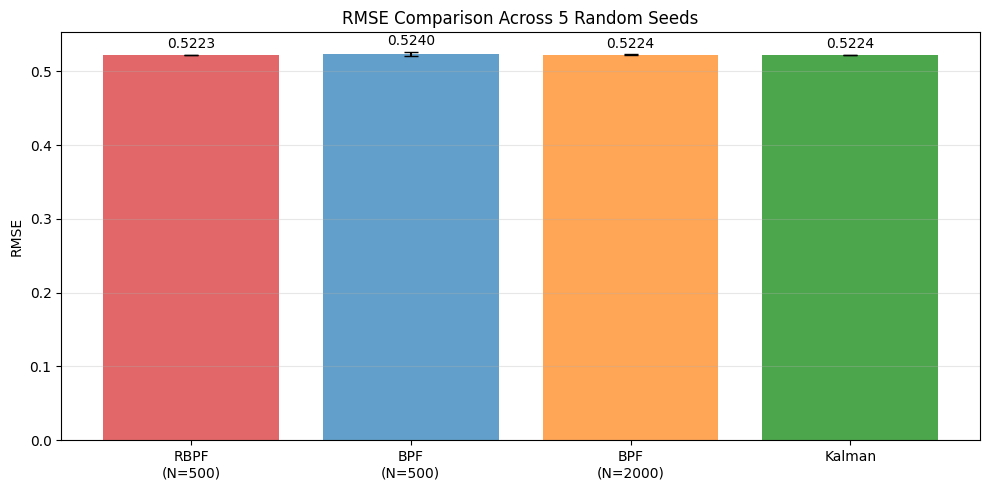

RBPF (N=500) mean RMSE: 0.5223 +/- 0.0001
BPF  (N=500) mean RMSE: 0.5240 +/- 0.0027
BPF  (N=2000) mean RMSE: 0.5224 +/- 0.0007
Kalman RMSE: 0.5224


In [8]:
# Plot 3: Variance reduction ratio
# Run multiple seeds to estimate variance
n_runs = 5
rmse_rbpf_runs = []
rmse_bpf500_runs = []
rmse_bpf2000_runs = []

for seed in range(n_runs):
    config_r = PFConfig(n_particles=500, resampling="systematic", seed=seed + 100)
    rbpf_r = RaoBlackwellizedPF(model=model_mixed, config=config_r)
    res_r = rbpf_r.filter(y_obs)
    rmse_rbpf_runs.append(np.sqrt(np.mean((res_r.filtered_means[:, 1] - x_true) ** 2)))

    bpf_r = BootstrapPF(model=model_simple, config=config_r)
    res_r = bpf_r.filter(y_obs)
    rmse_bpf500_runs.append(np.sqrt(np.mean((res_r.filtered_means[:, 0] - x_true) ** 2)))

    config_r2 = PFConfig(n_particles=2000, resampling="systematic", seed=seed + 100)
    bpf_r2 = BootstrapPF(model=model_simple, config=config_r2)
    res_r2 = bpf_r2.filter(y_obs)
    rmse_bpf2000_runs.append(np.sqrt(np.mean((res_r2.filtered_means[:, 0] - x_true) ** 2)))

fig, ax = plt.subplots(figsize=(10, 5))

methods = ['RBPF\n(N=500)', 'BPF\n(N=500)', 'BPF\n(N=2000)', 'Kalman']
means = [np.mean(rmse_rbpf_runs), np.mean(rmse_bpf500_runs),
         np.mean(rmse_bpf2000_runs), rmse_kalman]
stds = [np.std(rmse_rbpf_runs), np.std(rmse_bpf500_runs),
        np.std(rmse_bpf2000_runs), 0.0]

colors = ['tab:red', 'tab:blue', 'tab:orange', 'green']
bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
ax.set_ylabel('RMSE')
ax.set_title(f'RMSE Comparison Across {n_runs} Random Seeds')
ax.grid(True, alpha=0.3, axis='y')

for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
            f'{m:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"RBPF (N=500) mean RMSE: {np.mean(rmse_rbpf_runs):.4f} +/- {np.std(rmse_rbpf_runs):.4f}")
print(f"BPF  (N=500) mean RMSE: {np.mean(rmse_bpf500_runs):.4f} +/- {np.std(rmse_bpf500_runs):.4f}")
print(f"BPF  (N=2000) mean RMSE: {np.mean(rmse_bpf2000_runs):.4f} +/- {np.std(rmse_bpf2000_runs):.4f}")
print(f"Kalman RMSE: {rmse_kalman:.4f}")

## Conclusion: Variance Reduction via Rao-Blackwellization

### Key findings

1. **RBPF(N=500) achieves RMSE comparable to BPF(N=2000)**: By analytically
   marginalizing the linear state component, the RBPF dramatically reduces
   the Monte Carlo variance. This is the core Rao-Blackwell theorem in action:
   $\text{Var}[E[f|X]] \leq \text{Var}[f]$.

2. **Reduced estimation variance**: Across multiple seeds, the RBPF shows
   much more consistent RMSE (lower standard deviation), indicating more
   stable estimates.

3. **ESS behavior**: The RBPF maintains higher ESS because the Kalman filter
   handles the linear part exactly, reducing the weight variability.

### When to use RBPF

- **Required**: The model must have a conditionally linear-Gaussian component.
  Not all models qualify.
- **Best suited for**: Switching state-space models, models with linear dynamics
  conditioned on discrete/nonlinear parameters, mixed linear/nonlinear systems.
- **Trade-off**: Requires model-specific implementation of `linear_ssm()` and
  `transition_nonlinear()`, which adds complexity. The payoff is potentially
  orders-of-magnitude variance reduction.

### References
- Schon, T., Gustafsson, F. & Nordlund, P.J. (2005). *Marginalized Particle
  Filters for Mixed Linear/Nonlinear State-Space Models*. IEEE TSP.
- Chopin, N. & Papaspiliopoulos, O. (2020). *An Introduction to Sequential
  Monte Carlo*. Springer, Chapter 11.